In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\Unsupervised-ML\03_Hierarchical_Clustering\data\Global GDP Explorer 2025 (World Bank  UN Data).csv")

In [ ]:
df=df.drop(['Unnamed: 0'], axis=1)

In [8]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,United States,"$27,720,700,000,000",27.721 trillion,2.89,343477335,"$80,706",26.11%
1,China,"$17,794,800,000,000",17.795 trillion,5.25,1422584933,"$12,509",16.76%
2,Germany,"$4,525,700,000,000",4.526 trillion,-0.27,84548231,"$53,528",4.26%
3,Japan,"$4,204,490,000,000",4.204 trillion,1.68,124370947,"$33,806",3.96%
4,India,"$3,567,550,000,000",3.568 trillion,8.15,1438069596,"$2,481",3.36%


In [4]:
df['GDP Growth'].unique()

array(['2.89%', '5.25%', '−0.27%', '1.68%', '8.15%', '0.34%', '0.94%',
       '0.7%', '2.91%', '1.25%', '3.6%', '3.2%', '3.44%', '1.36%',
       '2.68%', '5.05%', '0.07%', '5.11%', '−0.76%', '0.72%', '0.14%',
       '−1.61%', '−0.31%', '−5.53%', '1.89%', '3.62%', '2.42%', '−0.95%',
       '1.07%', '0.48%', '5.78%', '5.55%', '2.5%', '5.04%', '3.56%',
       '3.76%', '3.28%', '2.86%', '0.61%', '2.4%', '−0.09%', '−0.04%',
       '0.22%', '−1.16%', '2.53%', '−0.55%', '5.1%', '0.73%', '−2.94%',
       '4.1%', '2.33%', '1.19%', '−0.91%', '5.32%', '−3.64%', '6.5%',
       '3.4%', '1.38%', '2.36%', '−20.11%', '1.31%', '5.56%', '3.53%',
       '6.29%', '−1.1%', '1%', '3.3%', '−2.3%', '7.4%', '3.85%', '5.07%',
       '6.2%', '0.37%', '2.94%', '1.12%', '3.89%', '2.11%', '0.96%',
       '8.56%', '6.3%', '3.25%', '5.34%', '0.04%', '2.98%', '75.06%',
       '3.08%', '10.16%', '4.71%', '4.96%', '1.71%', '−3.02%', '1.95%',
       '3.58%', '3.51%', '2.61%', '4.58%', '7.83%', '3.04%', '5.37%',
       '2

In [9]:
df['GDP Growth'] = (
    df['GDP Growth']
    .str.replace('%', '', regex=False)   # remove %
    .str.replace('−', '-', regex=False)  # fix unicode minus (very important)
    .str.strip()                         # remove spaces
)

In [10]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,United States,"$27,720,700,000,000",27.721 trillion,2.89,343477335,"$80,706",26.11%
1,China,"$17,794,800,000,000",17.795 trillion,5.25,1422584933,"$12,509",16.76%
2,Germany,"$4,525,700,000,000",4.526 trillion,-0.27,84548231,"$53,528",4.26%
3,Japan,"$4,204,490,000,000",4.204 trillion,1.68,124370947,"$33,806",3.96%
4,India,"$3,567,550,000,000",3.568 trillion,8.15,1438069596,"$2,481",3.36%


In [ ]:
df['GDP Growth'].unique()

array(['2.89', '5.25', '-0.27', '1.68', '8.15', '0.34', '0.94', '0.7',
       '2.91', '1.25', '3.6', '3.2', '3.44', '1.36', '2.68', '5.05',
       '0.07', '5.11', '-0.76', '0.72', '0.14', '-1.61', '-0.31', '-5.53',
       '1.89', '3.62', '2.42', '-0.95', '1.07', '0.48', '5.78', '5.55',
       '2.5', '5.04', '3.56', '3.76', '3.28', '2.86', '0.61', '2.4',
       '-0.09', '-0.04', '0.22', '-1.16', '2.53', '-0.55', '5.1', '0.73',
       '-2.94', '4.1', '2.33', '1.19', '-0.91', '5.32', '-3.64', '6.5',
       '3.4', '1.38', '2.36', '-20.11', '1.31', '5.56', '3.53', '6.29',
       '-1.1', '1', '3.3', '-2.3', '7.4', '3.85', '5.07', '6.2', '0.37',
       '2.94', '1.12', '3.89', '2.11', '0.96', '8.56', '6.3', '3.25',
       '5.34', '0.04', '2.98', '75.06', '3.08', '10.16', '4.71', '4.96',
       '1.71', '-3.02', '1.95', '3.58', '3.51', '2.61', '4.58', '7.83',
       '3.04', '5.37', '2.21', '1.35', '8.3', '3.94', '7.5', '6.74',
       '5.44', '4.66', '7.42', '2.96', '-1.86', '6.35', '2.2', '2.73'

In [12]:
df['GDP Growth'] = pd.to_numeric(df['GDP Growth'], errors='coerce')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              181 non-null    object 
 1   GDP (nominal, 2023)  181 non-null    object 
 2   GDP (abbrev.)        181 non-null    object 
 3   GDP Growth           181 non-null    float64
 4   Population 2023      181 non-null    int64  
 5   GDP per capita       181 non-null    object 
 6   Share of World GDP   181 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 10.0+ KB


In [15]:
df[df['GDP Growth'] < 0].shape

(22, 7)

In [16]:
df['GDP Growth'].isnull().sum()

np.int64(0)

In [17]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,United States,"$27,720,700,000,000",27.721 trillion,2.89,343477335,"$80,706",26.11%
1,China,"$17,794,800,000,000",17.795 trillion,5.25,1422584933,"$12,509",16.76%
2,Germany,"$4,525,700,000,000",4.526 trillion,-0.27,84548231,"$53,528",4.26%
3,Japan,"$4,204,490,000,000",4.204 trillion,1.68,124370947,"$33,806",3.96%
4,India,"$3,567,550,000,000",3.568 trillion,8.15,1438069596,"$2,481",3.36%


In [19]:
df['GDP (nominal, 2023)'] = df['GDP (nominal, 2023)'].replace('[\$,]', '', regex=True).astype(float)

df['GDP per capita'] = df['GDP per capita'].replace('[\$,]', '', regex=True).astype(float)

## Let us apply transformation

In [20]:
df['GDP_log'] = np.log1p(df['GDP (nominal, 2023)'])
df['Population_log'] = np.log1p(df['Population 2023'])
df['GDP_per_capita_log'] = np.log1p(df['GDP per capita'])

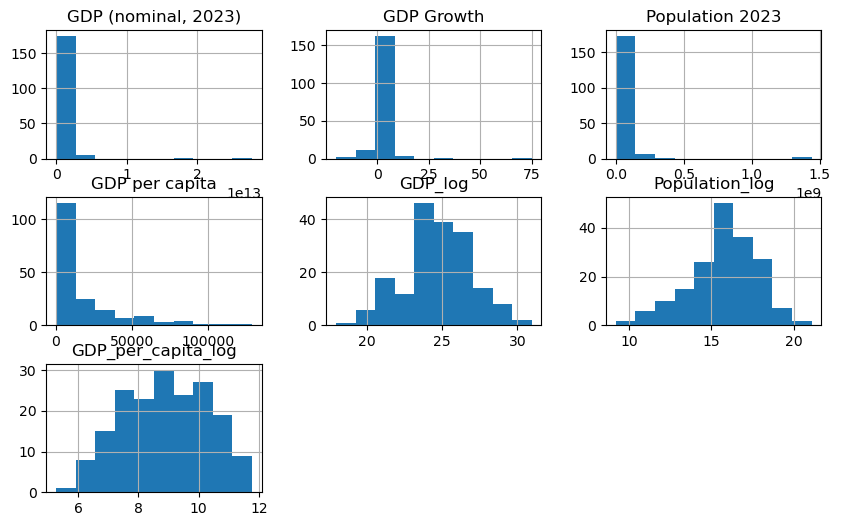

In [21]:
df.hist(figsize=(10, 6))
plt.show()

In [23]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP,GDP_log,Population_log,GDP_per_capita_log
0,United States,2.772070e+13,27.721 trillion,2.89,343477335,80706.0,26.11%,30.953201,19.654632,11.298581
1,China,1.779480e+13,17.795 trillion,5.25,1422584933,12509.0,16.76%,30.509927,21.075741,9.434284
2,Germany,4.525700e+12,4.526 trillion,-0.27,84548231,53528.0,4.26%,29.140793,18.252833,10.887979
3,Japan,4.204490e+12,4.204 trillion,1.68,124370947,33806.0,3.96%,29.067174,18.638779,10.428423
4,India,3.567550e+12,3.568 trillion,8.15,1438069596,2481.0,3.36%,28.902900,21.086567,7.816820


In [24]:
df.to_csv("cleaned_data.csv", index=False)